In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [2]:
# Load data
mafia_path = "/extdata4/baeklab/Hyeonseo/m6A/analyses/coverage/mafia.txt"
eligos_path = "/extdata4/baeklab/Hyeonseo/m6A/analyses/coverage/eligos.txt"
curlcake_path = "/extdata4/baeklab/Hyeonseo/m6A/analyses/coverage/curlcake.txt"

In [4]:
def read_path(path):
    with open(path, "r") as f:
        lines = f.readlines()
    lines = [line.strip() for line in lines]
    lines = [line for line in lines if (not line.startswith(">") and len(line) > 0)]
    return lines


In [5]:
mafia = read_path(mafia_path)
eligos = read_path(eligos_path)
curlcake = read_path(curlcake_path)


In [75]:
def count_kmer_mafia(lines,k=11,boi="A"):
    assert k % 2 == 1
    list_kmer = []
    for line in lines:
        line = line.replace("A/m6A", "A")
        len_line = len(line)
        assert len_line % 2 == 1
        central_kmer = line[len_line//2-(k//2):len_line//2+(k//2)+1]
        assert central_kmer[k//2] == boi
        list_kmer.append(central_kmer)
    count = len(set(list_kmer))
    return count

In [76]:
mafia_count = count_kmer_mafia(mafia, 11)
print(f"mafia: {mafia_count}")

mafia: 12


In [77]:
def count_kmer_ivt(lines,k=11,boi="A"):
    assert k % 2 == 1
    list_kmer = []
    half_k = k//2
    for line in tqdm.tqdm(lines):
        all_substrings = [line[i:i+k] for i in range(len(line)-k+1)]
        for substring in all_substrings:
            if substring[half_k] == boi:
                list_kmer.append(substring)
    count = len(set(list_kmer))
    return count
        

In [78]:
eligos_count = count_kmer_ivt(eligos, 11)
print(f"eligos: {eligos_count}")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 1065.63it/s]

eligos: 512


In [44]:
print(eligos_count/4**10)

0.0004949569702148438


In [34]:
curlcake_count = count_kmer_ivt(curlcake, 11)
print(f"curlcake: {curlcake_count}")

curlcake: 2454


In [46]:
print(curlcake_count/4**10)

0.0023403167724609375


In [10]:
def count_kmer_ivt(lines,k=11,boi="A"):
    assert k % 2 == 1
    list_kmer = []
    half_k = k//2
    for line in tqdm.tqdm(lines):
        all_substrings = [line[i:i+k] for i in range(len(line)-k+1)]
        for substring in all_substrings:
            if substring[half_k] == boi:
                list_kmer.append(substring)
    unique, counts = np.unique(list_kmer, return_counts=True)
    count_df = pd.DataFrame({"kmer": unique, "count": counts})
    return count_df


In [11]:
ivet_m6a_path = "/extdata4/baeklab/Hyeonseo/m6A/analyses/coverage/ivet/IVET_m6A_final/all.txt"
ivet_m6a = read_path(ivet_m6a_path)
ivet_m6a_df = count_kmer_ivt(ivet_m6a, 11)
print(ivet_m6a_df)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 205134/205134 [00:18<00:00, 10906.64it/s]


               kmer  count
0       AAAAAAAAAAA     63
1       AAAAAAAAAAC     16
2       AAAAAAAAAAG     50
3       AAAAAAAAAAT     26
4       AAAAAAAAACA     28
...             ...    ...
387630  TTTTTATTTGG      1
387631  TTTTTATTTGT     19
387632  TTTTTATTTTC     44
387633  TTTTTATTTTG      3
387634  TTTTTATTTTT    150

[387635 rows x 2 columns]


In [12]:
ivet_unmodified_path = "/extdata4/baeklab/Hyeonseo/m6A/analyses/coverage/ivet/IVET_unmodified_final/all.txt"
ivet_unmodified = read_path(ivet_unmodified_path)
ivet_unmodified_df = count_kmer_ivt(ivet_unmodified, 11)
print(ivet_unmodified_df)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 464903/464903 [00:34<00:00, 13292.69it/s]


               kmer  count
0       AAAAAAAAAAA    463
1       AAAAAAAAAAC    127
2       AAAAAAAAAAG    635
3       AAAAAAAAAAT    449
4       AAAAAAAAACA    546
...             ...    ...
341874  TTTTTATTTGT    108
341875  TTTTTATTTTA      3
341876  TTTTTATTTTC    422
341877  TTTTTATTTTG     14
341878  TTTTTATTTTT    477

[341879 rows x 2 columns]


In [13]:
print(ivet_m6a_df["count"].sum())
print(ivet_unmodified_df["count"].sum())

14879561
30535973


In [86]:
min_count = 100
ivet_df = pd.merge(ivet_m6a_df, ivet_unmodified_df, on="kmer", how="outer", suffixes=("_m6a", "_unmodified"))
ivet_df.fillna(0, inplace=True)
ivet_count = np.sum((ivet_df["count_m6a"] > min_count) & (ivet_df["count_unmodified"] > min_count))
print(f"ivet: {ivet_count}")

ivet: 24947


In [79]:
print(f"MAFIA\t{mafia_count}\t{100*mafia_count/4**10:.3g}%")
print(f"Eligos\t{eligos_count}\t{100*eligos_count/4**10:.3g}%")
print(f"Curlcake\t{curlcake_count}\t{100*curlcake_count/4**10:.3g}%")
print(f"IVET\t{ivet_count}\t{100*ivet_count/4**10:.3g}%")
print(f"AIR\t{4 ** 10}\t100%")

MAFIA	12	0.00114%
Eligos	512	0.0488%
Curlcake	2454	0.234%
IVET	117634	11.2%
AIR	1048576	100%


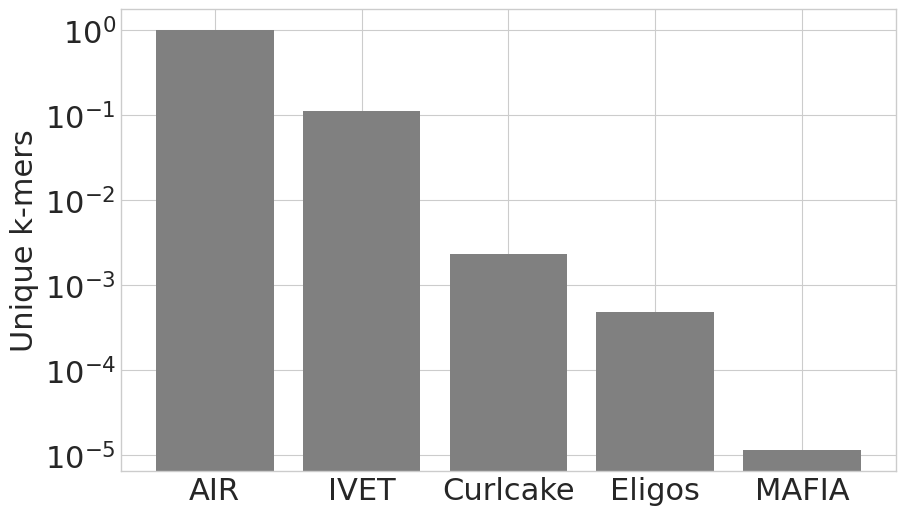

In [85]:
## Bar plot
fig, ax = plt.subplots(figsize=(10, 6))
data = np.array([mafia_count, eligos_count, curlcake_count, ivet_count, 4**10][::-1])/4**10
labels = ["MAFIA", "Eligos", "Curlcake", "IVET", "AIR"][::-1]
ax.bar(labels, data, color="gray")
ax.set_ylabel("Unique k-mers")
ax.set_yscale("log")
plt.show()


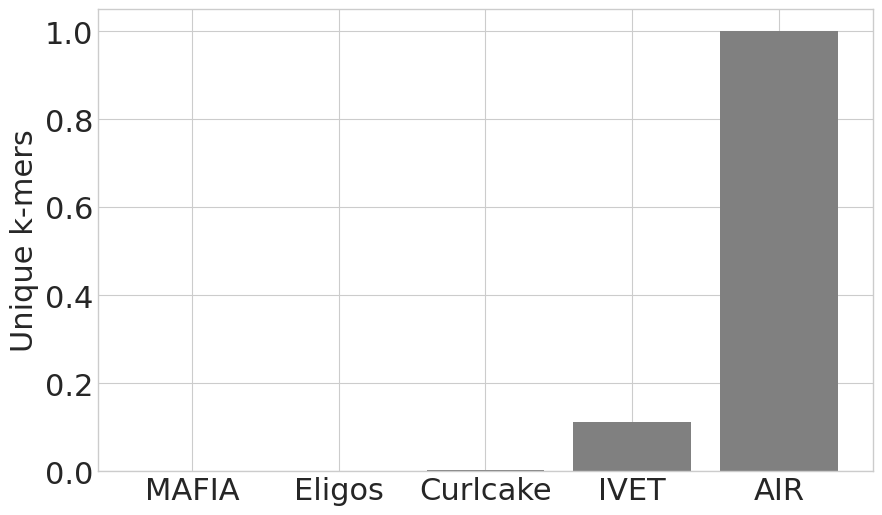

In [83]:
## Bar plot
fig, ax = plt.subplots(figsize=(10, 6))
data = np.array([mafia_count, eligos_count, curlcake_count, ivet_count, 4**10])/4**10
labels = ["MAFIA", "Eligos", "Curlcake", "IVET", "AIR"]
ax.bar(labels, data, color="gray")
ax.set_ylabel("Unique k-mers")
plt.show()


In [35]:
paths = glob.glob("/extdata4/baeklab/Hyeonseo/m6A/res/dataset/curlcake/*.csv")
dfs = []
for path in paths:
    df = pd.read_csv(path)
    dfs.append(df)
df = pd.concat(dfs)
print(len(df))

198955


In [36]:
print(df[(df["relative_pos"]==0)&(df["Ref"].notna())&(df["Ref_base"]=="A")]["Depth"].sum())

237888940.0


In [38]:
fasta_path = "/extdata4/baeklab/Hyeonseo/m6A/res/dataset/eligos/SRR11550255.fasta"
seqs = read_path(fasta_path)

In [39]:
a_count = 0
for seq in tqdm.tqdm(seqs):
    a_count += seq.count("A")
print(a_count)

176246072


In [40]:
fasta_path = "/extdata4/baeklab/Hyeonseo/m6A/res/dataset/eligos/SRR11550246.fasta"
seqs = read_path(fasta_path)

In [41]:
a_count = 0
for seq in tqdm.tqdm(seqs):
    a_count += seq.count("A")
print(a_count)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3427291/3427291 [00:02<00:00, 1512286.56it/s]

47102182
